# Concate 

- it stckes dataFrames ( Datasets ) togather 
- by default it Vertical ( on DF on Top of Other)

- can make it horizontal by axis = 1

        pd.concat([df1, df2])

- when we this the indexes are like 1st one df ( df1 ) starts from 0 till end. then df2 starts there from 0 till end

- if we want to make indexis so that it starts from 0 and goes till end of df2 in continues manner ( dont start from 0 again )
the use

        pd.concat([df1,df2], ignore_index=True)


- We can also make them multi Index one 0-based and One our own
- if we have two dfs one has data of NOV and one has data of DEC
- We can give the WHole Nov Table Index Nov and DEC table Dec 


                pd.concat([df1, df2], keys = ["Nov", "Dec"])

- now it will be multi indexed one 0-based and One key based i.e Nov



# Joins / Merge 
- we Aplly Join using Merge Function

                pd.merge(df1,df2,on="Common Col")


## Inner Join ( intersection )
- Both Tables Must have Common Col 
- Keep only Rows That Exist in both Tales

                pd.merge(df1, df2, on="Common Col", how="inner")

## Left Join:
- Keep All Rows from Left Table
- If Right Table Doesnt Have it Fill it wth NAN

                pd.merge(df1, df2, on="Common Col", how="left")

## Right Join:

- same as Left but for right

                pd.merge(df1, df2, on="Common Col", how="right")

## Outer Join (Union):
- Keep Everythg From Both Cols

        pd.merge(df1, df2, on="Common Col", how="outer")



In [2]:
import pandas as pd

# Datasets
- courses.csv
- students.csv
- reg-month1
- reg-month2

- deliveries.csv
- matches.cdv

In [3]:
students = pd.read_csv("students.csv")
regs = pd.read_csv("courses.csv")
nov = pd.read_csv("reg-month1.csv")
dec = pd.read_csv("reg-month2.csv")

In [ ]:
pd.concat([nov, dec]) # see the reslut after 24 index starts from 0 again ( dev )

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [ ]:
pd.concat([nov, dec] , ignore_index=True) # Now it will have contines 0-based indexinf

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [ ]:
# using keys parameter
pd.concat([nov, dec], keys=["Nov", "Dec"])

student_id  course_id
Nov 0           23          1
    1           15          5
    2           18          6
    3           23          4
    4           16          9
    5           18          1
    6            1          1
    7            7          8
    8           22          3
    9           15          1
    10          19          4
    11           1          6
    12           7         10
    13          11          7
    14          13          3
    15          24          4
    16          21          1
    17          16          5
    18          23          3
    19          17          7
    20          23          6
    21          25          1
    22          19          2
    23          25         10
    24           3          3
Dec 0            3          5
    1           16          7
    2           12         10
    3           12          1
    4           14          9
    5            7          7
    6            7          2
    7           16          3
    8           17         10
    9           11          8
    10          14          6
    11          12          5
    12          12          7
    13          18          8
    14           1         10
    15           1          9
    16           2          5
    17           7          6
    18          22          5
    19          22          6
    20          23          9
    21          23          5
    22          14          4
    23          14          1
    24          11         10
    25          42          9
    26          50          8
    27          38          1

In [18]:
both = pd.concat([nov,dec], keys=["Nov", "Dec"])
print ( both.loc["Nov"].head(2) )# -->> gives Nov data top 2
print ( both.loc["Dec"].tail(4) )
# print 0 index in Nov

print()
print( both.loc[("Nov", 0)])
print()
print( both.loc[("Dec", 2)])
print()
print( both.loc[("Dec", 3)])

   student_id  course_id
0          23          1
1          15          5
    student_id  course_id
24          11         10
25          42          9
26          50          8
27          38          1

student_id    23
course_id      1
Name: (Nov, 0), dtype: int64

student_id    12
course_id     10
Name: (Dec, 2), dtype: int64

student_id    12
course_id      1
Name: (Dec, 3), dtype: int64




# Joins / Merge 
- we Aplly Join using Merge Function

                pd.merge(df1,df2,on="Common Col")


## Inner Join ( intersection )
- Both Tables Must have Common Col 
- Keep only Rows That Exist in both Tales

                pd.merge(df1, df2, on="Common Col", how="inner")

## Left Join:
- Keep All Rows from Left Table
- If Right Table Doesnt Have it Fill it wth NAN

                pd.merge(df1, df2, on="Common Col", how="left")

## Right Join:

- same as Left but for right

                pd.merge(df1, df2, on="Common Col", how="right")

## Outer Join (Union):
- Keep Everythg From Both Cols

        pd.merge(df1, df2, on="Common Col", how="outer")

# Inner Join:

    employees  ← basic info
    projects   ← projects
    assignments ← which employee works on which project


    employees
        |
        | emp_id
        |
    assignments
        |
        | project_id
        |
    projects

In [21]:
import pandas as pd

# Employees table
employees = pd.DataFrame({
"emp_id":[1,2,3,4,5,6,7,8,9,10,
          11,12,13,14,15,16,17,18,19,20,
          21,22,23,24,25,26,27,28,29,30,
          31,32,33,34,35,36,37,38,39,40],

"name":[
"Ali","Sara","Ahmed","Zara","Usman","Hina","Bilal","Ayesha","Omar","Fatima",
"Sana","Hamza","Amir","Noor","Tariq","Mona","Sameer","Iqra","Raza","Nida",
"Talha","Anaya","Hashir","Laiba","Fahad","Sidra","Saad","Hassan","Mehwish","Asad",
"Danish","Saba","Usama","Maryam","Imran","Kiran","Zain","Sadia","Kamran","Rabia"
],

"department":[
"AI","ML","AI","Backend","Frontend","AI","DevOps","ML","AI","Data",
"Backend","AI","ML","Data","QA","DevOps","AI","ML","AI","Frontend",
"Data","Backend","ML","AI","AI","QA","Backend","DevOps","ML","AI",
"Frontend","AI","Data","Backend","ML","AI","DevOps","QA","AI","ML"
],

"city":[
"Lahore","Karachi","Islamabad","Lahore","Multan","Karachi","Lahore","Islamabad","Karachi","Lahore",
"Multan","Islamabad","Karachi","Lahore","Lahore","Karachi","Islamabad","Lahore","Multan","Karachi",
"Islamabad","Lahore","Karachi","Multan","Lahore","Islamabad","Karachi","Lahore","Multan","Karachi",
"Lahore","Islamabad","Karachi","Multan","Lahore","Karachi","Islamabad","Lahore","Multan","Karachi"
]
})


# Projects table
projects = pd.DataFrame({
"project_id":[101,102,103,104,105,106,107,108,109,110],
"project_name":[
"Chatbot AI","Fraud Detection","Recommendation System","Autonomous Driving",
"NLP Translation","AI Tutor","Stock Prediction","Medical Diagnosis",
"Voice Assistant","Image Recognition"
],
"budget":[200000,150000,180000,250000,120000,140000,160000,220000,130000,210000]
})


# Assignments table
assignments = pd.DataFrame({
"emp_id":[1,2,3,4,5,6,7,8,9,10,
          11,12,13,14,15,16,17,18,19,20,
          21,22,23,24,25,26,27,28,29,30],

"project_id":[
101,101,102,103,104,105,101,106,107,108,
109,110,102,103,104,105,106,107,108,109,
110,101,102,103,104,105,106,107,108,109
]
})

In [28]:
employees

,emp_id,name,department,city
0,1,Ali,AI,Lahore
1,2,Sara,ML,Karachi
2,3,Ahmed,AI,Islamabad
3,4,Zara,Backend,Lahore
4,5,Usman,Frontend,Multan
5,6,Hina,AI,Karachi
6,7,Bilal,DevOps,Lahore
7,8,Ayesha,ML,Islamabad
8,9,Omar,AI,Karachi
9,10,Fatima,Data,Lahore


In [29]:
pd.merge(employees, assignments, on= "emp_id", how="inner")
# Employees 31–40 disappear because they have no assignment.

,emp_id,name,department,city,project_id
0,1,Ali,AI,Lahore,101
1,2,Sara,ML,Karachi,101
2,3,Ahmed,AI,Islamabad,102
3,4,Zara,Backend,Lahore,103
4,5,Usman,Frontend,Multan,104
5,6,Hina,AI,Karachi,105
6,7,Bilal,DevOps,Lahore,101
7,8,Ayesha,ML,Islamabad,106
8,9,Omar,AI,Karachi,107
9,10,Fatima,Data,Lahore,108


In [30]:
pd.merge(assignments, projects, on="project_id", how="inner")

,emp_id,project_id,project_name,budget
0,1,101,Chatbot AI,200000
1,2,101,Chatbot AI,200000
2,3,102,Fraud Detection,150000
3,4,103,Recommendation System,180000
4,5,104,Autonomous Driving,250000
5,6,105,NLP Translation,120000
6,7,101,Chatbot AI,200000
7,8,106,AI Tutor,140000
8,9,107,Stock Prediction,160000
9,10,108,Medical Diagnosis,220000


In [34]:
# Employees Working on "Chatbot AI"
df = pd.merge(assignments, employees, on="emp_id" , how="inner") # we merged these two tables
df = pd.merge(df, projects, on="project_id" , how="inner") # now with Merged Table we merged Projects table

print(df.head(2))
print()

df[df["project_name"] == "Chatbot AI"]

   emp_id  project_id  name department     city project_name  budget
0       1         101   Ali         AI   Lahore   Chatbot AI  200000
1       2         101  Sara         ML  Karachi   Chatbot AI  200000



,emp_id,project_id,name,department,city,project_name,budget
0,1,101,Ali,AI,Lahore,Chatbot AI,200000
1,2,101,Sara,ML,Karachi,Chatbot AI,200000
6,7,101,Bilal,DevOps,Lahore,Chatbot AI,200000
21,22,101,Anaya,Backend,Lahore,Chatbot AI,200000


In [36]:
# ML Department Employees Working on Projects
df = pd.merge(assignments, employees, on="emp_id" , how="inner")
print( df.head(2))
print()

df[df["department"] == "ML"]

   emp_id  project_id  name department     city
0       1         101   Ali         AI   Lahore
1       2         101  Sara         ML  Karachi



,emp_id,project_id,name,department,city
1,2,101,Sara,ML,Karachi
7,8,106,Ayesha,ML,Islamabad
12,13,102,Amir,ML,Karachi
17,18,107,Iqra,ML,Lahore
22,23,102,Hashir,ML,Karachi
28,29,108,Mehwish,ML,Multan


In [40]:
# Projects With Employees From Lahore
df = pd.merge(assignments, employees, on="emp_id" , how= "inner")
df = pd.merge(df, projects, on="project_id" , how="inner")

print(df.head(2))
print()

df[df["city"] == "Lahore"]

   emp_id  project_id  name department     city project_name  budget
0       1         101   Ali         AI   Lahore   Chatbot AI  200000
1       2         101  Sara         ML  Karachi   Chatbot AI  200000



,emp_id,project_id,name,department,city,project_name,budget
0,1,101,Ali,AI,Lahore,Chatbot AI,200000
3,4,103,Zara,Backend,Lahore,Recommendation System,180000
6,7,101,Bilal,DevOps,Lahore,Chatbot AI,200000
9,10,108,Fatima,Data,Lahore,Medical Diagnosis,220000
13,14,103,Noor,Data,Lahore,Recommendation System,180000
14,15,104,Tariq,QA,Lahore,Autonomous Driving,250000
17,18,107,Iqra,ML,Lahore,Stock Prediction,160000
21,22,101,Anaya,Backend,Lahore,Chatbot AI,200000
24,25,104,Fahad,AI,Lahore,Autonomous Driving,250000
27,28,107,Hassan,DevOps,Lahore,Stock Prediction,160000


In [41]:
# AI Department Employees Working on NLP Translation
df = pd.merge(assignments, employees, on="emp_id" , how= "inner")
df = pd.merge(df, projects, on="project_id" , how="inner")

df[ ( df["department"] == "AI" ) & (df["project_name"] == "NLP Translation")] 

,emp_id,project_id,name,department,city,project_name,budget
5,6,105,Hina,AI,Karachi,NLP Translation,120000


# Left Join:
- Keep EVERYTHING from the left table
- Attach matching rows from the right table
- If no match → fill with NaN

In [42]:
pd.merge(employees, assignments, on="emp_id", how="left")

,emp_id,name,department,city,project_id
0,1,Ali,AI,Lahore,101.0
1,2,Sara,ML,Karachi,101.0
2,3,Ahmed,AI,Islamabad,102.0
3,4,Zara,Backend,Lahore,103.0
4,5,Usman,Frontend,Multan,104.0
5,6,Hina,AI,Karachi,105.0
6,7,Bilal,DevOps,Lahore,101.0
7,8,Ayesha,ML,Islamabad,106.0
8,9,Omar,AI,Karachi,107.0
9,10,Fatima,Data,Lahore,108.0


In [45]:
# Find employees with NO project assigned.
df = pd.merge(employees, assignments, on="emp_id", how="left")
df[df["project_id"].isnull()]


,emp_id,name,department,city,project_id
30,31,Danish,Frontend,Lahore,NaN
31,32,Saba,AI,Islamabad,NaN
32,33,Usama,Data,Karachi,NaN
33,34,Maryam,Backend,Multan,NaN
34,35,Imran,ML,Lahore,NaN
35,36,Kiran,AI,Karachi,NaN
36,37,Zain,DevOps,Islamabad,NaN
37,38,Sadia,QA,Lahore,NaN
38,39,Kamran,AI,Multan,NaN
39,40,Rabia,ML,Karachi,NaN


# Right Join is same as left: just on rght side

# Outer Join:

- Keep ALL rows from both tables
- Match rows where possible
- Fill NaN where there is no match

In [47]:
pd.merge(employees, assignments, how="outer", on="emp_id")

,emp_id,name,department,city,project_id
0,1,Ali,AI,Lahore,101.0
1,2,Sara,ML,Karachi,101.0
2,3,Ahmed,AI,Islamabad,102.0
3,4,Zara,Backend,Lahore,103.0
4,5,Usman,Frontend,Multan,104.0
5,6,Hina,AI,Karachi,105.0
6,7,Bilal,DevOps,Lahore,101.0
7,8,Ayesha,ML,Islamabad,106.0
8,9,Omar,AI,Karachi,107.0
9,10,Fatima,Data,Lahore,108.0


In [48]:
df = pd.merge(employees, assignments, on="emp_id", how="outer")

df = pd.merge(df, projects, on="project_id", how="outer")
df

,emp_id,name,department,city,project_id,project_name,budget
0,1,Ali,AI,Lahore,101.0,Chatbot AI,200000.0
1,2,Sara,ML,Karachi,101.0,Chatbot AI,200000.0
2,7,Bilal,DevOps,Lahore,101.0,Chatbot AI,200000.0
3,22,Anaya,Backend,Lahore,101.0,Chatbot AI,200000.0
4,3,Ahmed,AI,Islamabad,102.0,Fraud Detection,150000.0
5,13,Amir,ML,Karachi,102.0,Fraud Detection,150000.0
6,23,Hashir,ML,Karachi,102.0,Fraud Detection,150000.0
7,4,Zara,Backend,Lahore,103.0,Recommendation System,180000.0
8,14,Noor,Data,Lahore,103.0,Recommendation System,180000.0
9,24,Laiba,AI,Multan,103.0,Recommendation System,180000.0


# Inner Practice 


In [53]:
import pandas as pd

studentss = pd.DataFrame({
"id":[1,2,3,4],
"name":["Alyan","Aroosa","Sana","Alina"]
})

scores = pd.DataFrame({
"id":[1,2,2,5],
"score":[85,90,88,70]
})

In [54]:
studentss

,id,name
0,1,Alyan
1,2,Aroosa
2,3,Sana
3,4,Alina


In [52]:
scores

,id,score
0,1,85
1,2,90
2,2,88
3,5,70


In [ ]:
pd.merge(studentss, scores, on="id", how="inner")
# Inner Join get ID in Student and check it one by one in Scores
# 1st tym get 2 it checked 1 == 2 in Scores then 2 == 2 and print Aroose
# 2nd tym get 2 again it checked from start in scores 1 == 2 then 2 == 2 and print Aroosa

,id,name,score
0,1,Alyan,85
1,2,Aroosa,90
2,2,Aroosa,88


# From Data Sets

In [17]:
students = pd.read_csv("students.csv")
courses = pd.read_csv("courses.csv")
nov = pd.read_csv("reg-month1.csv")
dec = pd.read_csv("reg-month2.csv")

In [4]:
regs = pd.concat([nov,dec] , ignore_index=True)

In [65]:
pd.merge(students, regs, on="student_id", how="inner")

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [69]:
pd.merge(courses, regs, on="course_id", how="left")

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [73]:
# find Total revenue Genereated
df = pd.merge(regs, courses, how='inner', on="course_id")
df["price"].sum()

np.int64(154247)

In [19]:
# find revenue month by months
temp_def = pd.concat([nov, dec],keys=["Nov", "Dec"]).reset_index()
pd.merge(temp_def, courses, on="course_id").groupby("level_0")["price"].sum()


level_0
Dec    65072
Nov    89175
Name: price, dtype: int64

In [ ]:
# print the registreation Table 
# cols: name, Course, price

df = pd.merge(regs, students, on="student_id")
df = pd.merge(df,courses, on="course_id")
df[["name", "course_name", "price"]] # fancy Indexing


,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


<Axes: xlabel='course_name'>

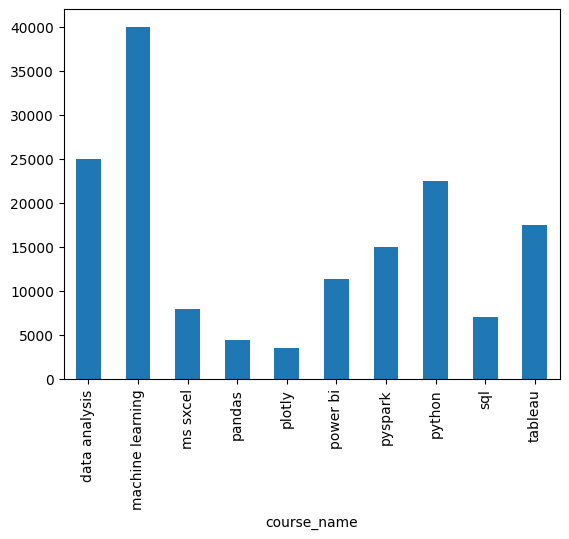

In [28]:
# plot a bar chart for revenue per course 
pd.merge(regs, courses, on="course_id").groupby("course_name")["price"].sum().plot(kind="bar")

In [34]:
# find Students Who Enrolled in Both Months 
import numpy as np
common_std_id = np.intersect1d( nov["student_id"],dec["student_id"] ) 
students [students["student_id"].isin(common_std_id)]


,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [35]:
# find course that go no enrollement
np.setdiff1d(courses["course_id"],regs["course_id"])

array([11, 12])